Implement K-Nearest Neighbors algorithm on social network dataset. Compute confusion matrix, accuracy, error rate, precision and recall on the given dataset.

Link to Dataset: https://www.kaggle.com/datasets/rakeshrau/social-network-ads


The dataset contains the details of users in a social networking site to find whether a user buys a product by clicking the ad on the site based on their salary, age, and gender.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [12]:
df = pd.read_csv("D:/KAUSTUBH/LP3 Final/Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [13]:
# Preprocessing: Encode 'Gender' and separate features and target
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])  # Female=0, Male=1

In [14]:
# Select features and target variable
X = df[['Age', 'EstimatedSalary', 'Gender']]
y = df['Purchased']
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You may tune 'n_neighbors' for optimal results
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [16]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

In [17]:
# Calculate performance metrics
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [18]:
# Display results
print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Confusion Matrix:
 [[69  4]
 [18 29]]
Accuracy: 0.82
Error Rate: 0.18
Precision: 0.88
Recall: 0.62


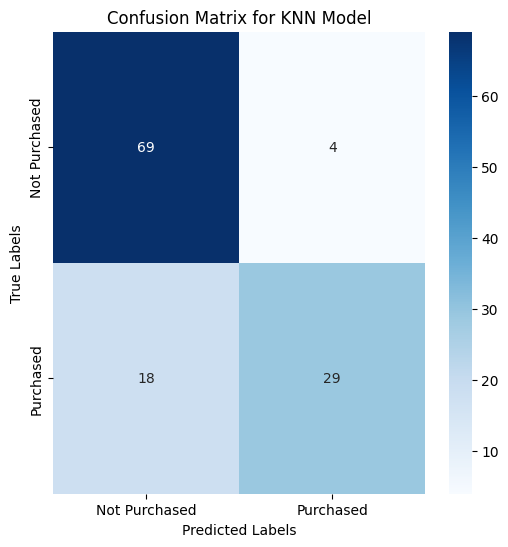

True Negatives: 69
False Positives: 4
False Negatives: 18
True Positives: 29


In [19]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for KNN Model")
plt.show()
# Extract values from the confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

### Different Performance Metrics in Machine Learning

In machine learning, **performance metrics** are used to evaluate how well a model is performing on a given task. The choice of performance metric depends on the type of problem (e.g., classification, regression) and the specific requirements of the task (e.g., handling imbalanced classes). Below is a comprehensive list of performance metrics, their formulas, and their meanings:

---

### **1. Accuracy**
**Formula**:  
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
Where:
- **TP** = True Positives: Correctly predicted positive instances
- **TN** = True Negatives: Correctly predicted negative instances
- **FP** = False Positives: Negative instances incorrectly classified as positive
- **FN** = False Negatives: Positive instances incorrectly classified as negative

**Meaning**:  
Accuracy measures the proportion of correct predictions (both true positives and true negatives) out of the total number of predictions. It is useful when the dataset is **balanced** (i.e., the classes are roughly equal in number).

**When to Use**:  
- When the class distribution is **balanced**.
- When false positives and false negatives are equally costly.

---

### **2. Precision**
**Formula**:  
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
Where:
- **TP** = True Positives
- **FP** = False Positives

**Meaning**:  
Precision measures the proportion of true positive predictions out of all the instances that were predicted as positive. It answers the question: *"Of all the positive predictions made by the model, how many were actually correct?"*

**When to Use**:  
- When **false positives** are costly or undesirable. For example, in fraud detection, you want to minimize the number of legitimate transactions being wrongly classified as fraud.
- When you care about the **quality** of positive predictions.

---

### **3. Recall (Sensitivity or True Positive Rate)**
**Formula**:  
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
Where:
- **TP** = True Positives
- **FN** = False Negatives

**Meaning**:  
Recall measures the proportion of actual positive instances that were correctly identified by the model. It answers the question: *"Of all the actual positive instances, how many did the model correctly identify?"*

**When to Use**:  
- When **false negatives** are costly or dangerous. For example, in medical diagnoses (e.g., cancer detection), you want to identify as many actual cases as possible, even if it means accepting a few false positives.
- When the goal is to **capture all positives**, regardless of the false positives.

---

### **4. F1 Score**
**Formula**:  
$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$
Where:
- **Precision** = $\frac{TP}{TP + FP}$
- **Recall** = $\frac{TP}{TP + FN}$

**Meaning**:  
The F1 score is the **harmonic mean** of precision and recall. It balances both precision and recall into a single metric, especially when you have imbalanced datasets. The F1 score is useful when you need a balance between **false positives** and **false negatives**.

**When to Use**:  
- When you need to balance **precision and recall** and cannot afford to focus too much on one at the expense of the other.
- In situations where **data imbalance** exists, and you need to ensure that both false positives and false negatives are minimized.

---

### **5. Specificity (True Negative Rate)**
**Formula**:  
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$
Where:
- **TN** = True Negatives
- **FP** = False Positives

**Meaning**:  
Specificity measures the proportion of actual negative instances that were correctly identified by the model. It answers the question: *"Of all the actual negative instances, how many did the model correctly identify?"*

**When to Use**:  
- When you want to measure the ability of the model to **correctly identify negative instances**.
- For example, in spam detection, specificity is useful for ensuring that non-spam emails are not misclassified as spam.

---

### **6. ROC Curve (Receiver Operating Characteristic Curve)**
**Definition**:  
The **ROC curve** is a graphical plot that illustrates the **performance of a binary classifier** as the decision threshold is varied. It plots:
- **True Positive Rate (TPR)** or **Recall** (on the Y-axis)  
- **False Positive Rate (FPR)** (on the X-axis)

**Meaning**:  
The ROC curve shows the trade-off between **sensitivity** (recall) and **specificity** across different thresholds. A curve that is closer to the top-left corner of the plot represents better performance. 

**When to Use**:  
- When you want to evaluate the model’s performance across all classification thresholds.
- When dealing with **binary classification problems**.

---

### **7. AUC (Area Under the ROC Curve)**
**Formula**:  
AUC is the **area under the ROC curve**. It is a single number representing the overall ability of the model to discriminate between positive and negative classes.

**Meaning**:  
AUC represents the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance. AUC ranges from:
- **AUC = 1**: Perfect classifier
- **AUC = 0.5**: Random classifier (no discrimination)
- **AUC < 0.5**: The model is performing worse than random.

**When to Use**:  
- When you want to compare the overall performance of models, particularly when **class imbalance** exists.
- When you are interested in **how well the model distinguishes between classes**, regardless of the decision threshold.

---

### **8. Logarithmic Loss (Log Loss)**
**Formula**:  
$$
\text{Log Loss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$
Where:
- $y_i$ = Actual class label (0 or 1)
- $\hat{y}_i$ = Predicted probability of the positive class
- $N$ = Number of instances

**Meaning**:  
Log loss measures the **uncertainty** of the model's predictions. It is based on the **logarithmic function** of predicted probabilities, so it penalizes incorrect confident predictions more than less confident ones. The lower the log loss, the better the model.

**When to Use**:  
- When you care about the **probability estimates** of your predictions (e.g., in probabilistic models).
- When evaluating models that output probabilities rather than hard classifications.

---

### **9. Matthews Correlation Coefficient (MCC)**
**Formula**:  
$$
\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$
**Meaning**:  
MCC is a measure of the quality of binary classifications. It takes into account all four confusion matrix values (TP, TN, FP, FN) and returns a value between -1 and 1:
- **1**: Perfect prediction
- **0**: No better than random guessing
- **-1**: Completely wrong prediction

**When to Use**:  
- When you want a **balanced metric** that considers all parts of the confusion matrix, especially when you have an **imbalanced dataset**.

---

### **10. R-Squared (Coefficient of Determination)**
**Formula**:  
$$
R^2 = 1 - \frac{\sum (y_{\text{true}} - y_{\text{pred}})^2}{\sum (y_{\text{true}} - \bar{y})^2}
$$
Where:
- $y_{\text{true}}$ = Actual values
- $y_{\text{pred}}$ = Predicted values
- $\bar{y}$ = Mean of the actual values

**Meaning**:  
R-squared measures the proportion of the variance in the dependent variable that is predictable from the independent variables. It provides insight into how well the model fits the data.

**When to Use**:  
- For **regression problems**.
- To evaluate how well your model explains the variance in the target variable.